In [1]:
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy import integrate
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations
import gzip
from batfuns import *
from scipy.signal import savgol_filter
%matplotlib widget

## Load data

In [2]:
# load timeseries rpt data 
cell_name = "UMBL2022FEB_CELL152059"
file_path = "Z:/voltaiq_data/PROCESSED/UMBL2022FEB/" + cell_name + "/RPT.pkl.gz"

with gzip.open(file_path, "rb") as f:
    rpt_data_raw = pickle.load(f)
# df = df.sort_values(by=['Time [ms]'])
rpt_data_raw = rpt_data_raw.reset_index(drop=True)
# rpt_data_raw[['Time [ms]','RPT #','Test type', 'Protocol']]

In [3]:
# Separate timeseries data by protocol
rpt_num = 2
hppc = rpt_data_raw[(rpt_data_raw['RPT #']==rpt_num) & (rpt_data_raw['Protocol']=='HPPC')].iloc[0]  #HPPC
charge = rpt_data_raw[(rpt_data_raw['RPT #']==rpt_num) & (rpt_data_raw['Protocol']=='C/20 charge')].iloc[0] #C/20 Discharge
discharge = rpt_data_raw[(rpt_data_raw['RPT #']==rpt_num) & (rpt_data_raw['Protocol']=='C/20 discharge')].iloc[0] #C/20 Discharge
# rpt_data_raw[['Time [ms]','RPT #','Test type', 'Protocol']]

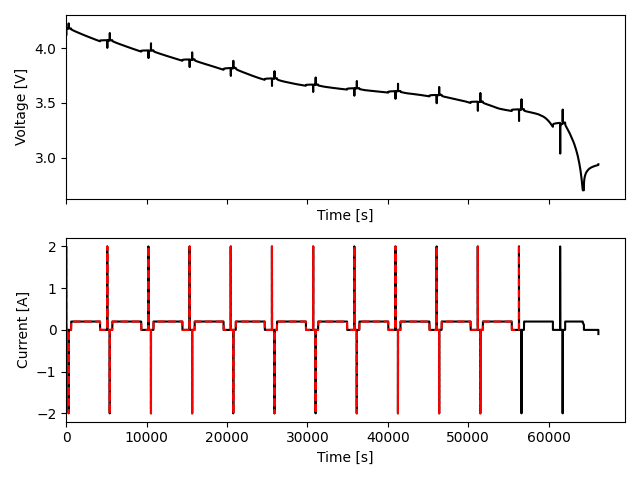

In [4]:
# plot subcycle data 
subcycle_data = hppc.Data
t_data = subcycle_data["Time [ms]"].to_numpy()/1000
t_data=t_data-t_data[0]
I_data = -subcycle_data['Current [A]'].to_numpy() # pybamm I>0 on discharge 
# I_data = np.interp(t_sim, t_data, I_data, left=None, right=None, period=None)
V_data= subcycle_data['Voltage [V]'].to_numpy()
# V_data = np.interp(t_sim, t_data, V_data, left=None, right=None, period=None)

fig,ax = plt.subplots(2,1, sharex = True)
ax1 = ax.flat[0]
ax1.plot(t_data,V_data,'k')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_data,I_data,'k')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()


# current profile for running sim
# t_sim = np.arange(0,t_data[-1],0.1)
# I_data_sim = np.interp(t_sim, t_data, I_data, left=None, right=None, period=None)
# V_data_sim = np.interp(t_sim, t_data, V_data, left=None, right=None, period=None)
df0 = pd.DataFrame({'t':t_data, 'I':I_data})
df = df0.drop_duplicates(subset='t', keep="last")
current_profile = df.iloc[0:-2100].to_numpy() #.iloc[0:3200] -2130
ax2.plot(current_profile[:,0],current_profile[:,1],'r--')


## Simulation set up 

In [5]:
model = pybamm.lithium_ion.SPMe() # for calculating parameters only

# update parameters 
parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Tran2025)
parameter_values.update(
    {
        "Maximum concentration in positive electrode [mol.m-3]": 31927.3,
        "Maximum concentration in negative electrode [mol.m-3]": 29637,
        "Upper voltage cut-off [V]": 4.3, 
        "Lower voltage cut-off [V]": 2.5, 
        },
    check_already_exists=False,
)    

# set initial concentrations from SOC using OCV from C/20 discharge
# Calculate initial SOC
I_ocv = -charge.Data['Current [A]']
t_ocv = charge.Data.loc[I_ocv<0,'Time [ms]']/1000
SOC_ocv = (integrate.cumulative_trapezoid(-I_ocv[I_ocv<0],t_ocv/3600,initial=0))/charge['Charge capacity [A.h]']
V_ocv = charge.Data.loc[I_ocv<0,'Voltage [V]']
V_0 = subcycle_data['Voltage [V]'].iloc[0]
SOC_0 = np.interp(V_0, V_ocv, SOC_ocv) # V_ocv needs to be increasing

try: 
    Cn = charge.Cn
    Cp =charge.Cp
    x100 = charge.x100
    x0 = charge.x0
    y100=charge.y100
    y0=charge.y0
except: 
    # if any(np.isnan([Cn, Cp, x100, x0, y100,y0])):
    C_n_init = 4.06-1
    C_p_init =5.5-1
    x_init = 0.852
    y_init = 0.309
    Cn, Cp, x100, x0, y100, y0 = calculate_eSOH(C_n_init, C_p_init, x_init, y_init,model, parameter_values)
x_init = (x100-x0)*SOC_0 + x0 
y_init = (y100-y0)*SOC_0 + y0 

param = model.param
eps_n_init = parameter_values.evaluate(Cn*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_init = parameter_values.evaluate(Cp*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)

# Updating parameters for initialization
parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_init,
        "Positive electrode active material volume fraction": eps_p_init,
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
    },
    check_already_exists=False,
)

print(f"SOC_0: {SOC_0}") 
print(f"x0: {x0}") 
print(f"x100: {x100}") 
print(f"y0: {y0}") 
print(f"y100: {y100}") 
print(f"Cn (usable): {(x100-x0)*Cn}") 
print(f"Cp (usable): {(y0-y100)*Cp}") 


SOC_0: 0.9891404347490963
x0: 0.0055
x100: 0.8161
y0: 0.9433
y100: 0.3029
Cn (usable): 2.55898314
Cp (usable): 2.55878224


In [6]:
# programming the pulse is faster to run than using input current. data also at 0.1Hz...
experiment = pybamm.Experiment(
        ["Rest for 1 second", 
        "Run current_profile (A)",
        ],
        drive_cycles={
            'current_profile': current_profile
        }, period = "1 second"
    )

In [7]:
models=[pybamm.lithium_ion.SPMe(name="SPMe")] #pybamm.lithium_ion.SPM(name="SPM"),
sols=[]
for model in models:
    print(model.name)
    # simulate subcycle with interpolant (30s for hppc with SPM or 2 min with SPMe?)
    sim = pybamm.Simulation(model, experiment=experiment,
                            parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("fast with events"))
    sols.append(sim.solve()) #initial_soc=SOC_0

SPMe


SPMe


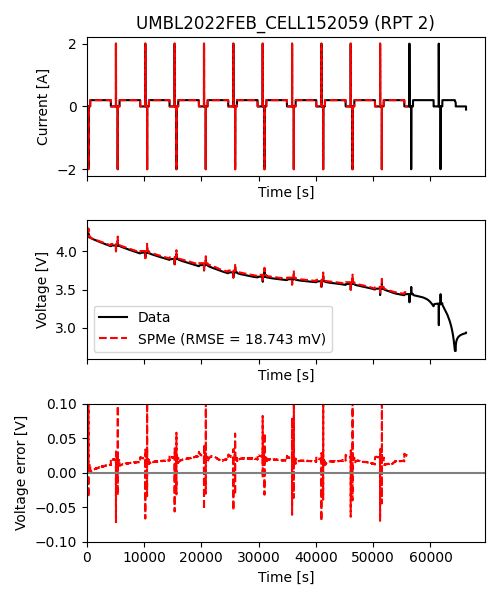

In [ ]:
fig,axs = plt.subplots(3,1,figsize=(5,6), sharex=True)
# plt.subplots_adjust(left=0.12, bottom=0.12, right=0.99, top=0.90) #, wspace=0.5, hspace=0.1
axs = axs.flatten()
linestyles = ['r--', 'b:']
for (model,sol,ls) in zip(models,sols,linestyles):
    print(model.name)
    # plot data and sim results 
    t = sol["Time [s]"].entries
    I = sol["Current [A]"].entries
    Q = sol['Discharge capacity [A.h]'].entries
    Vt = sol["Terminal voltage [V]"].entries


    ax = axs[0]
    ax.plot(t_data,I_data,'k', label = 'Data')
    ax.plot(t,I,ls,  label = model.name)
    ax.set_xlim(left=0)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Current [A]')
    ax.set_title(cell_name + f' (RPT {rpt_num})')

    ax = axs[1]
    e_V = Vt - np.interp(t,t_data, V_data)
    rmse_v = np.sqrt(np.mean(e_V**2))
    ax.plot(t_data,V_data,'k', label = 'Data')
    ax.plot(t,Vt,ls,  label = model.name + f' (RMSE = {round(rmse_v*1000,3)} mV)')
    ax.set_xlim(left=0)
    ax.set_ylim([2.6,4.4])
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage [V]')
    ax.legend(loc='lower left')

    ax = axs[2]
    ax.plot(t,e_V,ls)
    xlims = ax.get_xlim()
    ax.plot(xlims, [0]*2, 'grey')
    ax.set_xlim(left=0)
    ax.set_ylim([-0.1,0.1])
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage error [V]')

fig.tight_layout()
# handles, labels = axs[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol = 2, bbox_to_anchor=(0.5, 1), fancybox=True) #prop={'size': 10},  
plt.savefig('./figs/' + cell_name + '.jpg',format='jpg',dpi=300)

interactive(children=(FloatSlider(value=0.0, description='t', max=15.564722222222223, step=0.15564722222222221…

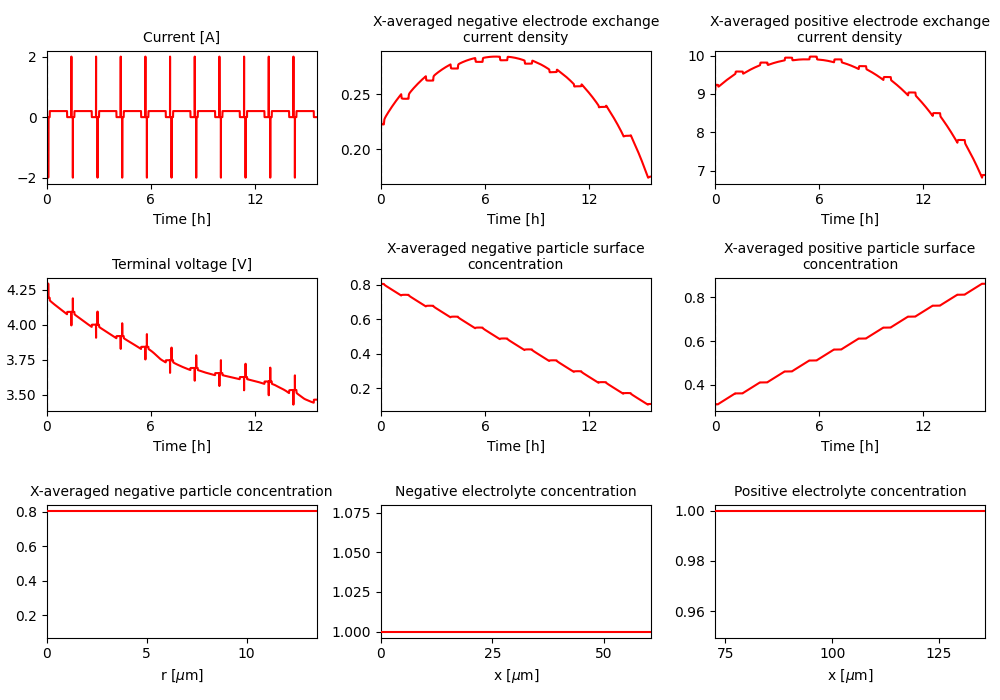

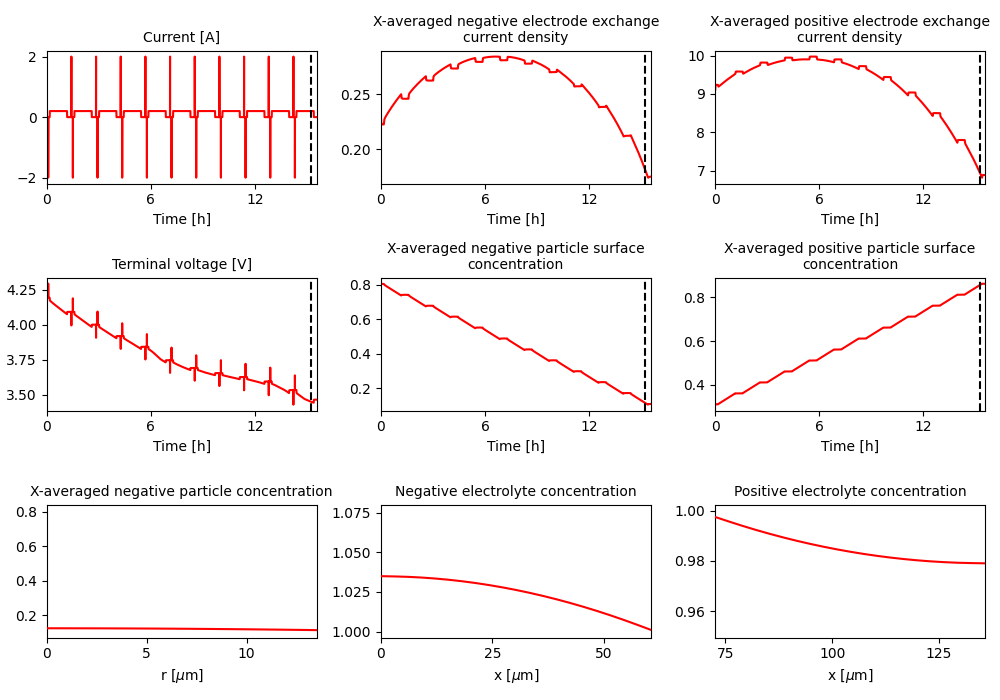

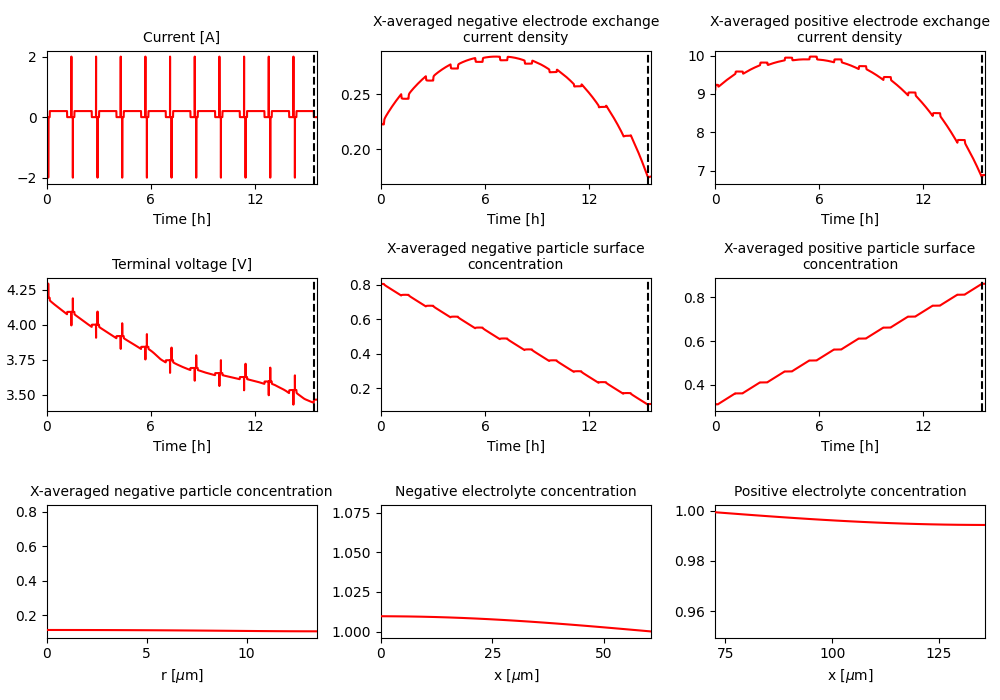

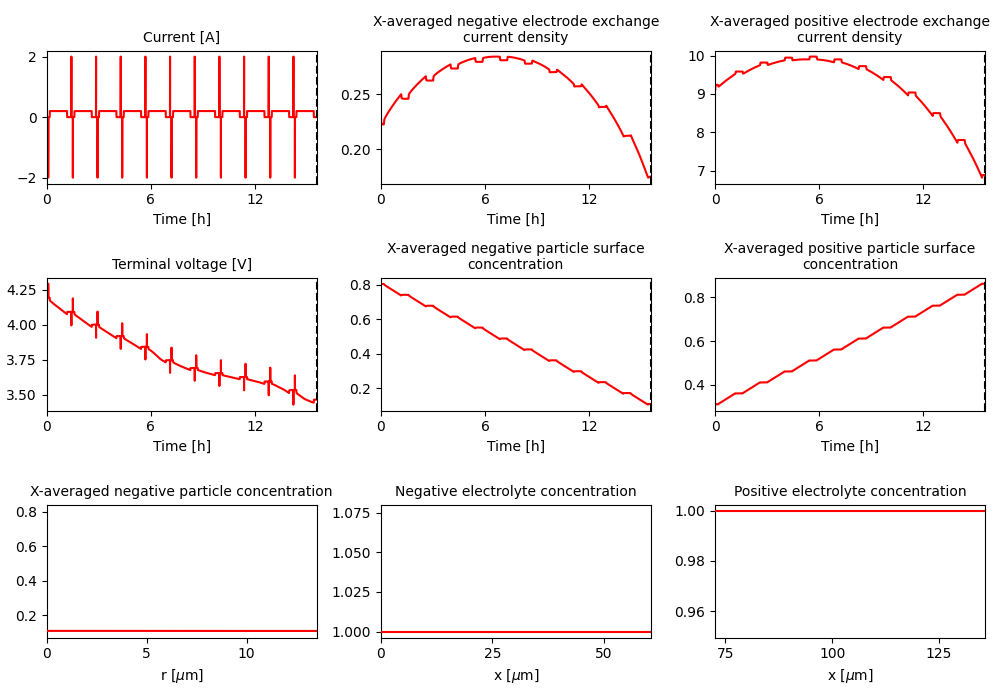

In [ ]:
%matplotlib widget

solution = sols[0]
quick_plot = pybamm.QuickPlot(solution, figsize=[10,7],n_rows = 3, output_variables=[ 
    'Current [A]', 
    'X-averaged negative electrode exchange current density',# [A.m-2]',
    'X-averaged positive electrode exchange current density',# [A.m-2]',

    'Terminal voltage [V]',
    'X-averaged negative particle surface concentration',
    'X-averaged positive particle surface concentration',

    # 'Volume-averaged cell temperature [K]',
    # 'Cell temperature [K]',
    # 'Decomposition heating [W.m-3]',
    'X-averaged negative particle concentration', 
    # 'X-averaged positive particle concentration',

    # 'Discharge capacity [A.h]',
    'Negative electrolyte concentration',# [mol.m-3]',
    'Positive electrolyte concentration',# [mol.m-3]',
    ])
quick_plot.dynamic_plot()

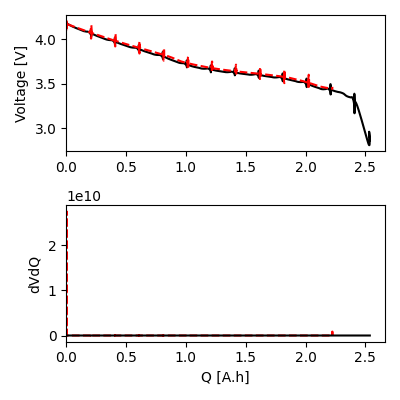

In [19]:
# filter, calculate, and plot dQdV from data and sim results 
if np.mean(I_data)<0: # charge
    Ah_sim=integrate.cumtrapz(-I,t,initial=0)/3600
    Ah_data=integrate.cumtrapz(-I_data,t_data,initial=0)/3600
else:# discharge
    Ah_sim=integrate.cumtrapz(I,t,initial=0)/3600
    Ah_data=integrate.cumtrapz(I_data,t_data,initial=0)/3600


# sgolay filter data and calculate dVdQ
window_length=501
polyorder=5
Qf_d = savgol_filter(Ah_data,window_length,polyorder)
dQ_d = savgol_filter(Ah_data,window_length,polyorder,1)
Vf_d = savgol_filter(V_data,window_length,polyorder)
dV_d = savgol_filter(V_data,window_length,polyorder,1)
dVdQ_d = dV_d/dQ_d

# sgolay filter sim results and calculate dVdQ
window_length=51
polyorder=5
Qf_s = savgol_filter(Ah_sim,window_length,polyorder)
dQ_s = savgol_filter(Ah_sim,window_length,polyorder,1)
Vf_s = savgol_filter(Vt,window_length,polyorder)
dV_s = savgol_filter(Vt,window_length,polyorder,1)
dVdQ_s = dV_s/dQ_s

# plot data vs sim dVdQ
fig,ax = plt.subplots(2,1,figsize=(4,4))
ax1 = ax.flat[0]
ax1.plot(Qf_d,Vf_d,'k')
ax1.plot(Qf_s,Vf_s,'r--')
ax1.set_xlim(left=0)

ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(Qf_s,dVdQ_s,'r--')
ax2.plot(Qf_d,dVdQ_d,'k')
ax2.set_xlim(left=0)
# ax2.set_ylim([-2,2])
ax2.set_ylim([0,2])
ax2.set_xlabel('Q [A.h]')
ax2.set_ylabel('dVdQ')
fig.tight_layout()

plt.savefig('./figs/' + cell_name + '_dqdv.jpg',format='jpg',dpi=300)


# Archive

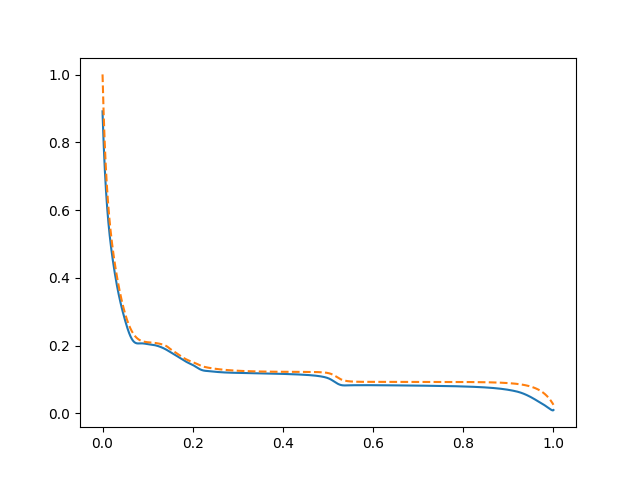

No such comm: 34ff505497a3498fb89c61347eaeb325


In [30]:
# plot Un fit
fn = r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm\input\parameters\lithium_ion\negative_electrodes\graphite_UMBL_Tran2025\graphite_ocp_Siegel.csv' 
Un_data = pd.read_csv(fn, comment='#', header = None, names = ["x", "Un"])
sto = Un_data.x


var=[-3.54049607669295,0.00708244334002580,0.00774192469266890, 
4.26893363759502,-0.0164043013936254,-4.05401806281007, 
0.0426131798578846,-3.19444157210193,0.0503611972394406, 
0.170261138869476,0.147567301186300,0.0382504766072001, 
0.519446050169237,1.10619736534131,0.0145120887836752, 
-0.0816693980616928,-0.0119716740325398,-0.00723858739498425, 
-0.0877677643234304,0.0238786887373114,0.0452264234816890, 
-0.00713413913218840]

p_eq=var[0:8]
a_eq=var[8:15]
b_eq = var[15:]
u_eq2=p_eq[-1]+p_eq[-2]*np.exp((sto-a_eq[-1])/b_eq[-1])
for i in range(6):
    u_eq2 += p_eq[i]*np.tanh((sto-a_eq[i])/b_eq[i])

var = [-2.74740857138957,0.00443109156371119,0.0140962302368559, 
    3.10348817994589,-0.0128948359572101,-4.36083705035769, 
    0.0643328570911640,-3.88703879262989,0.0631828141079049, 
    0.213012646348329,0.174731100372283,0.0577291579271751, 
    0.518982409471130,1.21588542781399,0.0150389780167150, 
    -0.0584524226380269,-0.00702394962468186,-0.0342305292048576, 
    -0.0619846453717142,0.0123530018211038,0.0873816814557679, 
    -0.00843321991754559]
p_eq=var[0:8]
a_eq=var[8:15]
b_eq = var[15:]
u_eq1=p_eq[-1]+p_eq[-2]*np.exp((sto-a_eq[-1])/b_eq[-1])
for i in range(6):
    u_eq1 += p_eq[i]*np.tanh((sto-a_eq[i])/b_eq[i])

Un_fit = (u_eq1 + u_eq2)/2#+0.02

plt.close('all')
plt.plot(Un_data.x, Un_data.Un)
plt.plot(Un_data.x, Un_fit, '--')
# plt.plot(Up_data.y, Up_fit2)
plt.show()

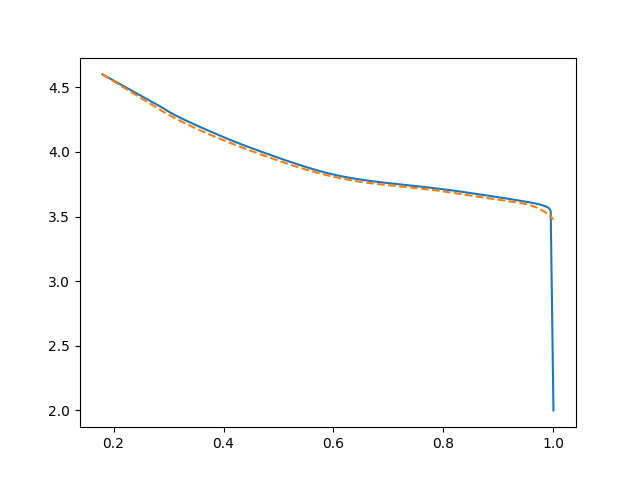

No such comm: c14ad255da484ef6a908fb3f04d3411b


In [ ]:
# plot Up fit
fn = r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm\input\parameters\lithium_ion\positive_electrodes\NMC_UMBL_Tran2025\NMC_ocp_Siegel.csv' 
Up_data = pd.read_csv(fn, comment='#', header = None, names = ["y", "Up"])


p1 = -2253.9364
p2 = 10756.6071
p3 = -21755.8183
p4 = 24277.2504
p5 = -16299.5659
p6 = 6728.9153
p7 = -1670.2785
p8 = 233.2321
p9 = -18.3223#*0.999
p10 = 5.3936

sto = Up_data.y
Up_fit = p1*sto**9 + p2*sto**8 + p3*sto**7 + p4*sto**6 + p5*sto**5 + p6*sto**4 + p7*sto**3 + p8*sto**2 + p9*sto + p10

# p = np.polyfit(Up_data.y, Up_data.Up, 10)
# Up_fit2 = np.polyval(p, sto)


plt.close('all')
plt.plot(Up_data.y, Up_data.Up)
plt.plot(Up_data.y, Up_fit,'--')
# plt.plot(Up_data.y, Up_fit2)
plt.show()

4.19395542
1.0


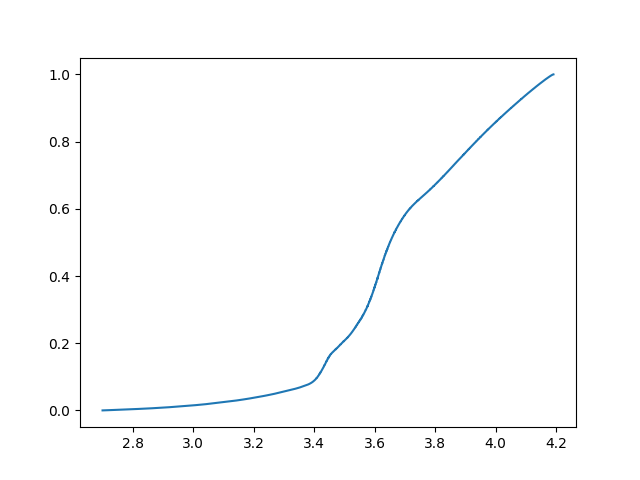

In [ ]:
I_d = abs(discharge.Data['Current [A]'])
t_d = discharge.Data.loc[I_d>0,'Time [ms]']/1000
V_ocv = discharge.Data.loc[I_d>0,'Voltage [V]']
SOC_ocv = (discharge['Discharge capacity [A.h]']-integrate.cumtrapz(I_d[I_d>0],t_d/3600,initial=0))/discharge['Discharge capacity [A.h]']
V_0 = subcycle_data['Voltage [V]'].iloc[0]
SOC_0 = np.interp(4.2, V_ocv[::-1], SOC_ocv[::-1]) # V_ocv needs to be increasing
print(V_0)
print(SOC_0)
plt.close('all')
plt.plot(V_ocv,SOC_ocv)
plt.show()

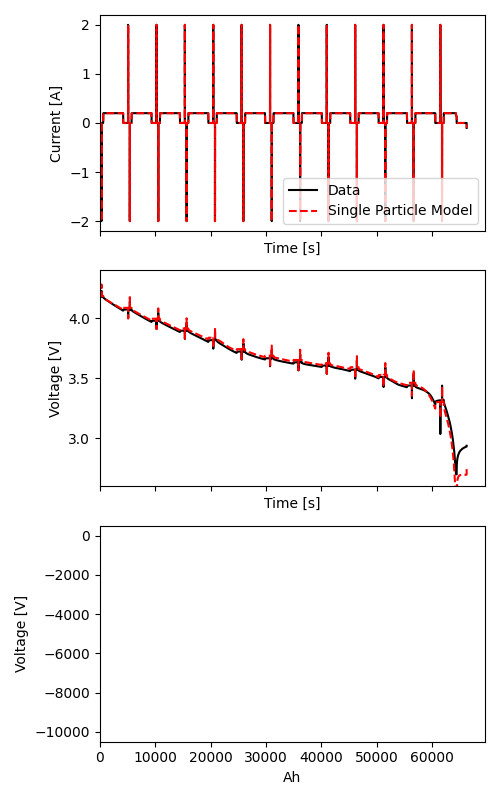

In [ ]:
# plot data and sim results 
t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries
if np.mean(I_data)<0:
    Ah_data=integrate.cumtrapz(-I_data,t_data,initial=0)/3600
    Ah_sim=integrate.cumtrapz(-I,t,initial=0)/3600
else:
    Ah_data=integrate.cumtrapz(I_data,t_data,initial=0)/3600
    Ah_sim=integrate.cumtrapz(I,t,initial=0)/3600


fig,axs = plt.subplots(3,1,figsize=(5,8))#,sharex=True)
axs = axs.flatten()
ax = axs[0]
ax.plot(t_data,I_data,'k', label = 'Data')
ax.plot(t,I,'r--',  label = model.name)
ax.legend()
ax.set_xlim(left=0)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Current [A]')


ax = axs[1]
ax.plot(t_data,V_data,'k')
ax.plot(t,Vt,'r--')
ax.set_xlim(left=0)
ax.set_ylim([2.6,4.4])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')


ax = axs[2]
ax.plot(Ah_data,V_data,'k')
ax.plot(Ah_sim,Vt,'r--')
ax.set_xlim(left=0)
ax.set_xlabel('Ah')
ax.set_ylabel('Voltage [V]')
fig.tight_layout()

